# Causal intervention for global-pathway broadcast mitigation

This notebook extends the two-layer broadcast-sink toy task with an explicit global pathway and an all-layer common-mode penalty. For each sequence,

$$
j^\star=\arg\max_j\langle x_j,u\rangle,
\qquad
y_i=x_i+\alpha(x_{j^\star}R),
$$

so one content-dependent payload must be delivered to every token.

We train matched versions of:

1. **Attention baseline**: the original two-layer model.
2. **Global pathway**: attention plus a learned global pooling-and-broadcast branch.
3. **Global pathway + penalty**: the same architecture with a normalized common-mode penalty on the **pre-gate, pre-LayerScale attention output in every layer**. The toy model contains neither gates nor LayerScale, so this is simply the projected attention update before it enters the residual stream.

For layer $\ell$, the penalty is

$$
\mathcal R_\ell
=
\mathbb E_b\left[
\frac{\|P_{\mathrm{com}}O^{\ell,\mathrm{attn}}_b\|_F^2}
{\operatorname{sg}(\|O^{\ell,\mathrm{attn}}_b\|_F^2)+\varepsilon}
\right],
\qquad
P_{\mathrm{com}}=\frac1n\mathbf1\mathbf1^\top,
$$

and $\mathcal L=\mathcal L_{\mathrm{MSE}}+\lambda_B\frac12(\mathcal R_1+\mathcal R_2)$. The ratio is computed per example and then averaged.

After training, attention interventions from the original notebook are retained and supplemented with global-pathway ablation, donor-state patching, and source-value interventions. A successful relocation should preserve task performance, reduce the causal effects of attention-side interventions, and increase the effects of global ablation or donor-state replacement.

In [ ]:
from pathlib import Path
import math
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Set BROADCAST_RUN_MODE=smoke for a fast end-to-end check.
RUN_MODE = os.environ.get("BROADCAST_RUN_MODE", "full").lower()
if RUN_MODE not in {"full", "smoke"}:
    raise ValueError("BROADCAST_RUN_MODE must be 'full' or 'smoke'")

DMODEL = 64
HEAD_DIM = 64
SEQ_LEN = 32
ALPHA = 1.0

if RUN_MODE == "full":
    TRAIN_BATCH_SIZE = 1024
    TRAIN_STEPS = 30_000
    EVAL_BATCHES = 64
    EVAL_BATCH_SIZE = 256
else:
    TRAIN_BATCH_SIZE = 32
    TRAIN_STEPS = 3
    EVAL_BATCHES = 1
    EVAL_BATCH_SIZE = 16

LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
LAMBDA_B = 1.0
PENALTY_EPS = 1e-12
TRAIN_IF_MISSING = True

CHECKPOINT_DIR = Path("broadcast_global_pathway_checkpoints")
OUTPUT_DIR = Path("broadcast_global_pathway_outputs")
CHECKPOINT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

VARIANTS = {
    "Attention baseline": {"use_global": False, "lambda_b": 0.0},
    "Global pathway": {"use_global": True, "lambda_b": 0.0},
    "Global pathway + penalty": {"use_global": True, "lambda_b": LAMBDA_B},
}

sns.set_theme(style="whitegrid", context="talk")
print({
    "run_mode": RUN_MODE,
    "train_steps": TRAIN_STEPS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batches": EVAL_BATCHES,
})

device: cuda
{'run_mode': 'full', 'train_steps': 30000, 'train_batch_size': 1024, 'eval_batches': 64}


## Model

The global branch pools normalized token representations once,

$$
\pi_j^\ell=\operatorname{softmax}_j((w_P^\ell)^\top z_j^\ell),
\qquad
g^\ell=\sum_j\pi_j^\ell W_{V,G}^\ell z_j^\ell,
$$

then delivers $W_{O,G}^\ell g^\ell$ uniformly to all recipients. Thus
$O^{\ell,\mathrm{global}}=\mathbf1(W_{O,G}^\ell g^\ell)^\top$ lies exactly in the common subspace. There is no token-dependent recipient gate in this controlled experiment.

In [ ]:
class OneHeadWithGlobal(nn.Module):
    def __init__(self, d=DMODEL, h=HEAD_DIM, length=SEQ_LEN, add_pos=True):
        super().__init__()
        self.add_pos = add_pos
        self.norm = nn.LayerNorm(d)
        self.Wq = nn.Linear(d, h, bias=False)
        self.Wk = nn.Linear(d, h, bias=False)
        self.Wv = nn.Linear(d, h, bias=False)
        self.Wo = nn.Linear(h, d, bias=False)
        self.pos = nn.Parameter(torch.randn(length, d) * 0.02)

        # Explicit global pathway.
        self.global_score = nn.Linear(d, 1, bias=False)
        self.Wv_global = nn.Linear(d, h, bias=False)
        self.Wo_global = nn.Linear(h, d, bias=False)

    def attention_update(self, A, V):
        return self.Wo(A @ V)

    def global_payload_from_state(self, global_state):
        return self.Wo_global(global_state)

    def forward(self, x, use_global=False, ret=False):
        residual = x
        z = x + self.pos.unsqueeze(0) if self.add_pos else x
        z = self.norm(z)

        Q = self.Wq(z)
        K = self.Wk(z)
        V = self.Wv(z)
        scores = Q @ K.transpose(1, 2) / math.sqrt(Q.shape[-1])
        A = torch.softmax(scores, dim=-1)
        attn_update = self.attention_update(A, V)

        global_logits = self.global_score(z).squeeze(-1)
        global_weights = torch.softmax(global_logits, dim=-1)
        global_values = self.Wv_global(z)
        global_state = torch.einsum("bn,bnh->bh", global_weights, global_values)
        global_payload = self.global_payload_from_state(global_state)
        if use_global:
            global_update = global_payload.unsqueeze(1).expand_as(attn_update)
        else:
            global_update = torch.zeros_like(attn_update)

        output = residual + attn_update + global_update
        cache = {
            "Q": Q,
            "K": K,
            "V": V,
            "scores": scores,
            "A": A,
            "residual": residual,
            "z": z,
            "attention_update": attn_update,
            "global_logits": global_logits,
            "global_weights": global_weights,
            "global_values": global_values,
            "global_state": global_state,
            "global_payload": global_payload,
            "global_update": global_update,
            "use_global": use_global,
        }
        return (output, A, cache) if ret else output


class TwoLayerGlobal(nn.Module):
    def __init__(self, d=DMODEL, h=HEAD_DIM, length=SEQ_LEN, use_global=False):
        super().__init__()
        self.use_global = use_global
        self.l1 = OneHeadWithGlobal(d, h, length, add_pos=True)
        self.mlp1 = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 4 * d),
            nn.GELU(),
            nn.Linear(4 * d, d),
        )
        self.l2 = OneHeadWithGlobal(d, h, length, add_pos=False)
        self.mlp2 = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, 4 * d),
            nn.GELU(),
            nn.Linear(4 * d, d),
        )

    def forward(self, x, ret=False):
        l1_attn, A1, cache1 = self.l1(x, use_global=self.use_global, ret=True)
        h1 = l1_attn + self.mlp1(l1_attn)
        l2_attn, A2, cache2 = self.l2(h1, use_global=self.use_global, ret=True)
        output = l2_attn + self.mlp2(l2_attn)

        if not ret:
            return output

        cache = {
            "l1": cache1,
            "l2": cache2,
            "l1_attn": l1_attn,
            "h1": h1,
            "l2_attn": l2_attn,
        }
        return output, (A1, A2), cache


def make_task(x, u, R, alpha=ALPHA):
    j_star = (x @ u).argmax(dim=-1)
    batch = torch.arange(x.shape[0], device=x.device)
    selected_x = x[batch, j_star]
    payload = selected_x @ R
    target = x + alpha * payload.unsqueeze(1)
    return target, j_star, payload


def common_mode_ratio(update, eps=PENALTY_EPS):
    # ||P_com O||_F^2 / sg(||O||_F^2), evaluated per example.
    n = update.shape[1]
    common_energy = n * update.mean(dim=1).square().sum(dim=-1)
    total_energy = update.square().sum(dim=(1, 2)).detach()
    return (common_energy / (total_energy + eps)).mean()


def broadcast_penalty(cache):
    ratios = torch.stack([
        common_mode_ratio(cache["l1"]["attention_update"]),
        common_mode_ratio(cache["l2"]["attention_update"]),
    ])
    return ratios.mean(), ratios


# Fix one task across all variants.
task_generator = torch.Generator(device=device).manual_seed(SEED + 10)
u = torch.randn(DMODEL, generator=task_generator, device=device)
u = u / u.norm().clamp_min(1e-12)
matrix = torch.randn(DMODEL, DMODEL, generator=task_generator, device=device)
R, _ = torch.linalg.qr(matrix)
R = R.contiguous()

## Matched training

All variants see the same task parameters and the same pseudorandom training batches. Checkpoint names include the run mode, preventing a smoke-test checkpoint from being reused in a full experiment.

In [ ]:
def safe_name(name):
    return name.lower().replace(" + ", "_").replace(" ", "_")


def checkpoint_path(name):
    return CHECKPOINT_DIR / f"{safe_name(name)}_{RUN_MODE}.pt"


def train_variant(name, use_global, lambda_b):
    # Same initialization and same data stream for each condition.
    torch.manual_seed(SEED + 100)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + 100)
    model = TwoLayerGlobal(use_global=use_global).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    data_generator = torch.Generator(device=device).manual_seed(SEED + 1_000)

    model.train()
    for step in range(1, TRAIN_STEPS + 1):
        x = torch.randn(
            TRAIN_BATCH_SIZE, SEQ_LEN, DMODEL,
            generator=data_generator, device=device,
        )
        target, j_star, _ = make_task(x, u, R)
        output, (A1, A2), cache = model(x, ret=True)
        task_loss = F.mse_loss(output, target)
        penalty, layer_ratios = broadcast_penalty(cache)
        loss = task_loss + lambda_b * penalty

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        report_every = 5_000 if RUN_MODE == "full" else 1
        if step == 1 or step % report_every == 0:
            with torch.no_grad():
                batch = torch.arange(x.shape[0], device=device)
                a1_source = A1[batch, :, j_star].mean().item()
                a2_source = A2[batch, :, j_star].mean().item()
                p1_source = cache["l1"]["global_weights"][batch, j_star].mean().item()
                p2_source = cache["l2"]["global_weights"][batch, j_star].mean().item()
            print(
                f"{name:28s} | step {step:5d} | task {task_loss.item():.4e} | "
                f"penalty {penalty.item():.3f} | ratios "
                f"({layer_ratios[0].item():.3f}, {layer_ratios[1].item():.3f}) | "
                f"A->j* ({a1_source:.3f}, {a2_source:.3f}) | "
                f"pi(j*) ({p1_source:.3f}, {p2_source:.3f})"
            )
    return model.eval()


models = {}
for variant_name, config in VARIANTS.items():
    path = checkpoint_path(variant_name)
    if path.exists():
        checkpoint = torch.load(path, map_location=device)
        model = TwoLayerGlobal(use_global=config["use_global"]).to(device)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        models[variant_name] = model
        print(f"Loaded {path}")
    elif TRAIN_IF_MISSING:
        model = train_variant(variant_name, **config)
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "variant": variant_name,
                "config": config,
                "u": u.detach().cpu(),
                "R": R.detach().cpu(),
                "seed": SEED,
                "train_steps": TRAIN_STEPS,
                "alpha": ALPHA,
                "penalty": "mean over layers of per-example common-mode attention-output ratios",
            },
            path,
        )
        models[variant_name] = model
        print(f"Saved {path}")
    else:
        raise FileNotFoundError(f"Missing {path}; set TRAIN_IF_MISSING=True")

Attention baseline           | step     1 | task 1.1504e+00 | penalty 0.869 | ratios (0.862, 0.876) | A->j* (0.031, 0.031) | pi(j*) (0.027, 0.036)
Attention baseline           | step  5000 | task 3.1849e-01 | penalty 1.000 | ratios (1.000, 1.000) | A->j* (0.681, 0.681) | pi(j*) (0.027, 0.036)
Attention baseline           | step 10000 | task 3.0757e-01 | penalty 1.000 | ratios (1.000, 1.000) | A->j* (0.687, 0.689) | pi(j*) (0.028, 0.034)
Attention baseline           | step 15000 | task 3.1612e-01 | penalty 1.000 | ratios (1.000, 1.000) | A->j* (0.670, 0.678) | pi(j*) (0.028, 0.034)
Attention baseline           | step 20000 | task 3.0988e-01 | penalty 1.000 | ratios (1.000, 1.000) | A->j* (0.684, 0.688) | pi(j*) (0.028, 0.034)
Attention baseline           | step 25000 | task 3.0738e-01 | penalty 1.000 | ratios (1.000, 1.000) | A->j* (0.678, 0.682) | pi(j*) (0.028, 0.033)
Attention baseline           | step 30000 | task 3.1216e-01 | penalty 1.000 | ratios (1.000, 1.000) | A->j* (0.686, 0.

## Intervention mechanics

Each intervention is applied to one layer at a time. Layer-1 interventions are propagated through the first MLP and the complete second block; layer-2 interventions are propagated through the final MLP.

Attention-side interventions preserve the original global update. Global-side interventions preserve the original attention matrix and values. **Donor global state** replaces $g^\ell$ with the corresponding state from an independent donor sequence and passes it through the recipient model's $W_{O,G}^\ell$. Source-value interventions change a single $W_{V,G}z_j$ while preserving the pooling weights $\pi$.

In [ ]:
ATTENTION_INTERVENTIONS = [
    "Baseline",
    "Remove attention update",
    "Zero sink value",
    "Donor sink value",
    "Donor non-sink value",
    "Zero random non-sink value",
    "Redirect sink attention",
]

GLOBAL_INTERVENTIONS = [
    "Zero global pathway",
    "Donor global state",
    "Zero selected global value",
    "Donor selected global value",
]


def batch_gather(sequence, indices):
    batch = torch.arange(sequence.shape[0], device=sequence.device)
    return sequence[batch, indices]


def batch_scatter(sequence, indices, values):
    result = sequence.clone()
    batch = torch.arange(sequence.shape[0], device=sequence.device)
    result[batch, indices] = values
    return result


def choose_non_sink(j_star, length=SEQ_LEN):
    return (j_star + 1) % length


def recompute_local_output(head, cache, A=None, V=None, global_update=None):
    A = cache["A"] if A is None else A
    V = cache["V"] if V is None else V
    global_update = cache["global_update"] if global_update is None else global_update
    return cache["residual"] + head.attention_update(A, V) + global_update


def modify_attention(cache, donor_cache, j_star, donor_j_star, intervention):
    A = cache["A"]
    V = cache["V"]
    A_new = A
    V_new = V
    patched_index = j_star

    if intervention in {"Baseline", "Remove attention update"}:
        pass
    elif intervention == "Zero sink value":
        V_new = batch_scatter(V, j_star, torch.zeros_like(batch_gather(V, j_star)))
    elif intervention == "Donor sink value":
        V_new = batch_scatter(V, j_star, batch_gather(donor_cache["V"], donor_j_star))
    elif intervention == "Donor non-sink value":
        donor_non_sink = choose_non_sink(donor_j_star)
        V_new = batch_scatter(V, j_star, batch_gather(donor_cache["V"], donor_non_sink))
    elif intervention == "Zero random non-sink value":
        patched_index = choose_non_sink(j_star)
        V_new = batch_scatter(
            V, patched_index, torch.zeros_like(batch_gather(V, patched_index))
        )
    elif intervention == "Redirect sink attention":
        A_new = A.clone()
        batch = torch.arange(A.shape[0], device=A.device)
        A_new[batch, :, j_star] = 0.0
        A_new = A_new / A_new.sum(dim=-1, keepdim=True).clamp_min(1e-12)
    else:
        raise ValueError(f"Unknown attention intervention: {intervention}")

    return A_new, V_new, patched_index


def modify_global(head, cache, donor_cache, intervention):
    base_update = cache["global_update"]
    selected = cache["global_weights"].argmax(dim=-1)
    donor_selected = donor_cache["global_weights"].argmax(dim=-1)

    if intervention == "Zero global pathway":
        return torch.zeros_like(base_update), selected
    if intervention == "Donor global state":
        payload = head.global_payload_from_state(donor_cache["global_state"])
        return payload.unsqueeze(1).expand_as(base_update), selected

    values = cache["global_values"]
    if intervention == "Zero selected global value":
        values_new = batch_scatter(
            values, selected, torch.zeros_like(batch_gather(values, selected))
        )
    elif intervention == "Donor selected global value":
        donor_value = batch_gather(donor_cache["global_values"], donor_selected)
        values_new = batch_scatter(values, selected, donor_value)
    else:
        raise ValueError(f"Unknown global intervention: {intervention}")

    state_new = torch.einsum("bn,bnh->bh", cache["global_weights"], values_new)
    payload_new = head.global_payload_from_state(state_new)
    return payload_new.unsqueeze(1).expand_as(base_update), selected


@torch.no_grad()
def intervene_layer(model, x, donor_x, layer, intervention, j_star, donor_j_star):
    baseline, _, base_cache = model(x, ret=True)
    _, _, donor_cache = model(donor_x, ret=True)

    head = model.l1 if layer == "L1" else model.l2
    cache = base_cache[layer.lower()]
    donor_layer_cache = donor_cache[layer.lower()]
    A_new, V_new = cache["A"], cache["V"]
    global_new = cache["global_update"]
    pathway = "attention"
    patched_index = j_star

    if intervention in ATTENTION_INTERVENTIONS:
        A_new, V_new, patched_index = modify_attention(
            cache, donor_layer_cache, j_star, donor_j_star, intervention
        )
        if intervention == "Remove attention update":
            local_intervened = cache["residual"] + global_new
            predicted_delta = -cache["attention_update"]
        else:
            local_intervened = recompute_local_output(
                head, cache, A=A_new, V=V_new, global_update=global_new
            )
            predicted_delta = head.attention_update(A_new, V_new) - cache["attention_update"]
    elif intervention in GLOBAL_INTERVENTIONS:
        pathway = "global"
        if not model.use_global:
            return None
        global_new, patched_index = modify_global(
            head, cache, donor_layer_cache, intervention
        )
        local_intervened = recompute_local_output(
            head, cache, A=A_new, V=V_new, global_update=global_new
        )
        predicted_delta = global_new - cache["global_update"]
    else:
        raise ValueError(f"Unknown intervention: {intervention}")

    local_baseline = recompute_local_output(head, cache)
    local_delta = local_intervened - local_baseline
    torch.testing.assert_close(local_delta, predicted_delta, rtol=1e-4, atol=1e-5)

    if layer == "L1":
        h1 = local_intervened + model.mlp1(local_intervened)
        l2_attn = model.l2(h1, use_global=model.use_global)
        final = l2_attn + model.mlp2(l2_attn)
    elif layer == "L2":
        final = local_intervened + model.mlp2(local_intervened)
    else:
        raise ValueError("layer must be 'L1' or 'L2'")

    expected_local = base_cache["l1_attn" if layer == "L1" else "l2_attn"]
    torch.testing.assert_close(local_baseline, expected_local, rtol=1e-4, atol=1e-5)

    return {
        "baseline": baseline,
        "final": final,
        "local_delta": local_delta,
        "predicted_local_delta": predicted_delta,
        "pathway": pathway,
        "patched_index": patched_index,
    }

In [ ]:
def recipient_mask(j_star, length=SEQ_LEN):
    positions = torch.arange(length, device=j_star.device).unsqueeze(0)
    return positions != j_star.unsqueeze(1)


def masked_token_rms(tensor, mask):
    selected = tensor[mask]
    return selected.square().mean().sqrt().item()


def mean_recipient_vector(tensor, mask):
    weights = mask.unsqueeze(-1).to(tensor.dtype)
    return (tensor * weights).sum(dim=1) / weights.sum(dim=1).clamp_min(1.0)


def common_energy_fraction(tensor, mask=None):
    if mask is None:
        mask = torch.ones(tensor.shape[:2], dtype=torch.bool, device=tensor.device)
    weights = mask.unsqueeze(-1).to(tensor.dtype)
    mean = (tensor * weights).sum(dim=1) / weights.sum(dim=1).clamp_min(1.0)
    shared_energy = mean.square().sum(dim=-1) * weights.sum(dim=1).squeeze(-1)
    total_energy = (tensor.square() * weights).sum(dim=(1, 2))
    valid = total_energy > 1e-12
    if not valid.any():
        return float("nan")
    return (shared_energy[valid] / total_energy[valid]).mean().item()


def mean_cosine(a, b):
    valid = (a.norm(dim=-1) > 1e-10) & (b.norm(dim=-1) > 1e-10)
    if not valid.any():
        return float("nan")
    return F.cosine_similarity(a[valid], b[valid], dim=-1).mean().item()


def relative_error(actual, predicted):
    numerator = (actual - predicted).flatten(1).norm(dim=-1)
    denominator = predicted.flatten(1).norm(dim=-1)
    valid = denominator > 1e-10
    if not valid.any():
        return 0.0 if numerator.max().item() < 1e-10 else float("nan")
    return (numerator[valid] / denominator[valid]).mean().item()


@torch.no_grad()
def evaluate_models(models, u, R, n_batches=EVAL_BATCHES, batch_size=EVAL_BATCH_SIZE):
    result_rows = []
    routing_rows = []
    eval_generator = torch.Generator(device=device).manual_seed(SEED + 2_000)

    for batch_id in range(n_batches):
        x = torch.randn(
            batch_size, SEQ_LEN, DMODEL, generator=eval_generator, device=device
        )
        donor_x = torch.randn(
            batch_size, SEQ_LEN, DMODEL, generator=eval_generator, device=device
        )
        target, j_star, payload = make_task(x, u, R)
        _, donor_j_star, donor_payload = make_task(donor_x, u, R)
        donor_target = x + ALPHA * donor_payload.unsqueeze(1)
        no_payload_target = x
        recipients = recipient_mask(j_star)
        desired_transfer = ALPHA * (donor_payload - payload)
        batch = torch.arange(batch_size, device=device)

        for variant, model in models.items():
            model.eval()
            baseline, (A1, A2), cache = model(x, ret=True)

            for layer, A, layer_cache, head in [
                ("L1", A1, cache["l1"], model.l1),
                ("L2", A2, cache["l2"], model.l2),
            ]:
                column_mass = A.mean(dim=1)
                predicted_sink = column_mass.argmax(dim=-1)
                projected_values = head.Wo(layer_cache["V"])
                selected_projected = batch_gather(projected_values, j_star)
                nonsink = recipient_mask(j_star)
                non_sink_norm = projected_values.norm(dim=-1)[nonsink].mean().item()
                global_weights = layer_cache["global_weights"]
                predicted_global_source = global_weights.argmax(dim=-1)

                routing_rows.append({
                    "batch": batch_id,
                    "variant": variant,
                    "layer": layer,
                    "task_mse": F.mse_loss(baseline, target).item(),
                    "sink_match": (predicted_sink == j_star).float().mean().item(),
                    "max_column_inflow": column_mass.max(dim=-1).values.mean().item(),
                    "attention_to_selected": A[batch, :, j_star].mean().item(),
                    "attention_common_fraction": common_energy_fraction(
                        layer_cache["attention_update"]
                    ),
                    "selected_projected_value_norm": selected_projected.norm(dim=-1).mean().item(),
                    "non_sink_projected_value_norm": non_sink_norm,
                    "global_source_match": (
                        (predicted_global_source == j_star).float().mean().item()
                        if model.use_global else float("nan")
                    ),
                    "global_weight_to_selected": (
                        global_weights[batch, j_star].mean().item()
                        if model.use_global else float("nan")
                    ),
                    "global_common_fraction": (
                        common_energy_fraction(layer_cache["global_update"])
                        if model.use_global else float("nan")
                    ),
                    "attention_update_rms": layer_cache["attention_update"].square().mean().sqrt().item(),
                    "global_update_rms": layer_cache["global_update"].square().mean().sqrt().item(),
                })

                interventions = list(ATTENTION_INTERVENTIONS)
                if model.use_global:
                    interventions += GLOBAL_INTERVENTIONS

                for intervention in interventions:
                    out = intervene_layer(
                        model, x, donor_x, layer, intervention, j_star, donor_j_star
                    )
                    final_delta = out["final"] - out["baseline"]
                    local_delta = out["local_delta"]
                    predicted = out["predicted_local_delta"]
                    mean_final_change = mean_recipient_vector(final_delta, recipients)
                    donor_intervention = intervention in {
                        "Donor sink value",
                        "Donor global state",
                        "Donor selected global value",
                    }

                    result_rows.append({
                        "batch": batch_id,
                        "variant": variant,
                        "layer": layer,
                        "pathway": out["pathway"],
                        "intervention": intervention,
                        "task_mse": F.mse_loss(out["final"], target).item(),
                        "no_payload_mse": F.mse_loss(out["final"], no_payload_target).item(),
                        "donor_target_mse": F.mse_loss(out["final"], donor_target).item(),
                        "final_delta_rms_recipients": masked_token_rms(final_delta, recipients),
                        "local_delta_rms_recipients": masked_token_rms(local_delta, recipients),
                        "recipient_common_energy": common_energy_fraction(final_delta, recipients),
                        "local_prediction_cosine": mean_cosine(
                            local_delta.flatten(1), predicted.flatten(1)
                        ),
                        "local_prediction_relative_error": relative_error(local_delta, predicted),
                        "donor_payload_transfer_cosine": (
                            mean_cosine(mean_final_change, desired_transfer)
                            if donor_intervention else float("nan")
                        ),
                        "donor_target_improvement": (
                            F.mse_loss(baseline, donor_target).item()
                            - F.mse_loss(out["final"], donor_target).item()
                            if donor_intervention else float("nan")
                        ),
                    })

    return pd.DataFrame(result_rows), pd.DataFrame(routing_rows)


results, routing = evaluate_models(models, u, R)

summary = (
    results.groupby(["variant", "layer", "pathway", "intervention"], sort=False)
    .agg(
        task_mse_mean=("task_mse", "mean"),
        task_mse_sem=("task_mse", "sem"),
        no_payload_mse_mean=("no_payload_mse", "mean"),
        donor_target_mse_mean=("donor_target_mse", "mean"),
        final_delta_rms_mean=("final_delta_rms_recipients", "mean"),
        final_delta_rms_sem=("final_delta_rms_recipients", "sem"),
        local_delta_rms_mean=("local_delta_rms_recipients", "mean"),
        common_energy_mean=("recipient_common_energy", "mean"),
        local_prediction_cosine_mean=("local_prediction_cosine", "mean"),
        local_prediction_relative_error_mean=("local_prediction_relative_error", "mean"),
        donor_payload_transfer_cosine_mean=("donor_payload_transfer_cosine", "mean"),
        donor_target_improvement_mean=("donor_target_improvement", "mean"),
    )
    .reset_index()
)

routing_summary = (
    routing.groupby(["variant", "layer"], sort=False)
    .agg(
        task_mse_mean=("task_mse", "mean"),
        task_mse_sem=("task_mse", "sem"),
        sink_match_mean=("sink_match", "mean"),
        max_column_inflow_mean=("max_column_inflow", "mean"),
        attention_to_selected_mean=("attention_to_selected", "mean"),
        attention_common_fraction_mean=("attention_common_fraction", "mean"),
        global_source_match_mean=("global_source_match", "mean"),
        global_weight_to_selected_mean=("global_weight_to_selected", "mean"),
        attention_update_rms_mean=("attention_update_rms", "mean"),
        global_update_rms_mean=("global_update_rms", "mean"),
    )
    .reset_index()
)

display(routing_summary)
display(summary)

results.to_csv(OUTPUT_DIR / "causal_results.csv", index=False)
routing.to_csv(OUTPUT_DIR / "routing_results.csv", index=False)
summary.to_csv(OUTPUT_DIR / "causal_summary.csv", index=False)
routing_summary.to_csv(OUTPUT_DIR / "routing_summary.csv", index=False)

,variant,layer,task_mse_mean,task_mse_sem,sink_match_mean,max_column_inflow_mean,attention_to_selected_mean,attention_common_fraction_mean,global_source_match_mean,global_weight_to_selected_mean,attention_update_rms_mean,global_update_rms_mean
0,Attention baseline,L1,0.309289,0.003776,0.776733,0.769704,0.685093,0.999989,NaN,NaN,1.134007,0.000000
1,Attention baseline,L2,0.309289,0.003776,0.780396,0.773954,0.690819,0.999969,NaN,NaN,1.437553,0.000000
2,Global pathway,L1,0.309765,0.003755,0.717529,0.246778,0.231527,0.999439,0.775391,0.616963,0.214149,0.950875
3,Global pathway,L2,0.309765,0.003755,0.779785,0.790119,0.698662,0.999937,0.780579,0.668828,0.768092,0.626453
4,Global pathway + penalty,L1,0.364754,0.003488,0.015625,0.031250,0.031250,1.000000,0.069946,0.031251,0.000001,0.001303
5,Global pathway + penalty,L2,0.364754,0.003488,0.000000,0.134572,0.008326,0.202143,0.772705,0.651454,0.000016,2.553268


,variant,layer,pathway,intervention,task_mse_mean,task_mse_sem,no_payload_mse_mean,donor_target_mse_mean,final_delta_rms_mean,final_delta_rms_sem,local_delta_rms_mean,common_energy_mean,local_prediction_cosine_mean,local_prediction_relative_error_mean,donor_payload_transfer_cosine_mean,donor_target_improvement_mean
0,Attention baseline,L1,attention,Baseline,0.309289,0.003776,0.740123,1.662682,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN,NaN
1,Attention baseline,L1,attention,Remove attention update,2.776556,0.004617,1.633715,2.925012,1.533776e+00,1.548036e-03,1.134030e+00,0.696964,1.000000,3.773021e-08,NaN,NaN
2,Attention baseline,L1,attention,Zero sink value,1.752675,0.008730,1.149594,2.260822,1.141493e+00,4.533000e-03,8.646336e-01,0.886307,1.000000,1.737362e-07,NaN,NaN
3,Attention baseline,L1,attention,Donor sink value,0.351546,0.003808,0.706097,1.550010,1.559583e-01,1.004098e-03,2.525344e-01,0.995635,1.000000,6.865539e-07,0.471990,1.126721e-01
4,Attention baseline,L1,attention,Donor non-sink value,0.373852,0.003486,0.683625,1.629279,2.504695e-01,1.800606e-03,4.909803e-01,0.986029,1.000000,4.838752e-07,NaN,NaN
5,Attention baseline,L1,attention,Zero random non-sink value,0.312157,0.003812,0.746872,1.670634,7.262768e-02,4.318725e-03,6.717612e-02,0.717810,0.961707,1.885505e-01,NaN,NaN
6,Attention baseline,L1,attention,Redirect sink attention,0.347002,0.003799,0.714622,1.639933,1.366419e-01,8.086985e-04,2.354811e-01,0.994837,1.000000,8.765616e-07,NaN,NaN
7,Attention baseline,L2,attention,Baseline,0.309289,0.003776,0.740123,1.662682,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,0.000000e+00,NaN,NaN
8,Attention baseline,L2,attention,Remove attention update,2.335220,0.001825,1.597298,2.436581,1.423553e+00,7.421202e-04,1.437541e+00,0.999765,1.000000,3.077531e-08,NaN,NaN
9,Attention baseline,L2,attention,Zero sink value,1.845527,0.003578,1.073634,1.942481,1.147551e+00,3.235333e-03,1.156899e+00,0.999336,1.000000,1.452260e-07,NaN,NaN


## Primary causal relocation tests

The most direct comparison is between removing attention and removing the global pathway. Successful relocation predicts a small effect for **Remove attention update** and a large effect for **Zero global pathway**, especially in the penalized model. Donor-state replacement should transfer the donor payload direction if the global branch carries the shared signal.

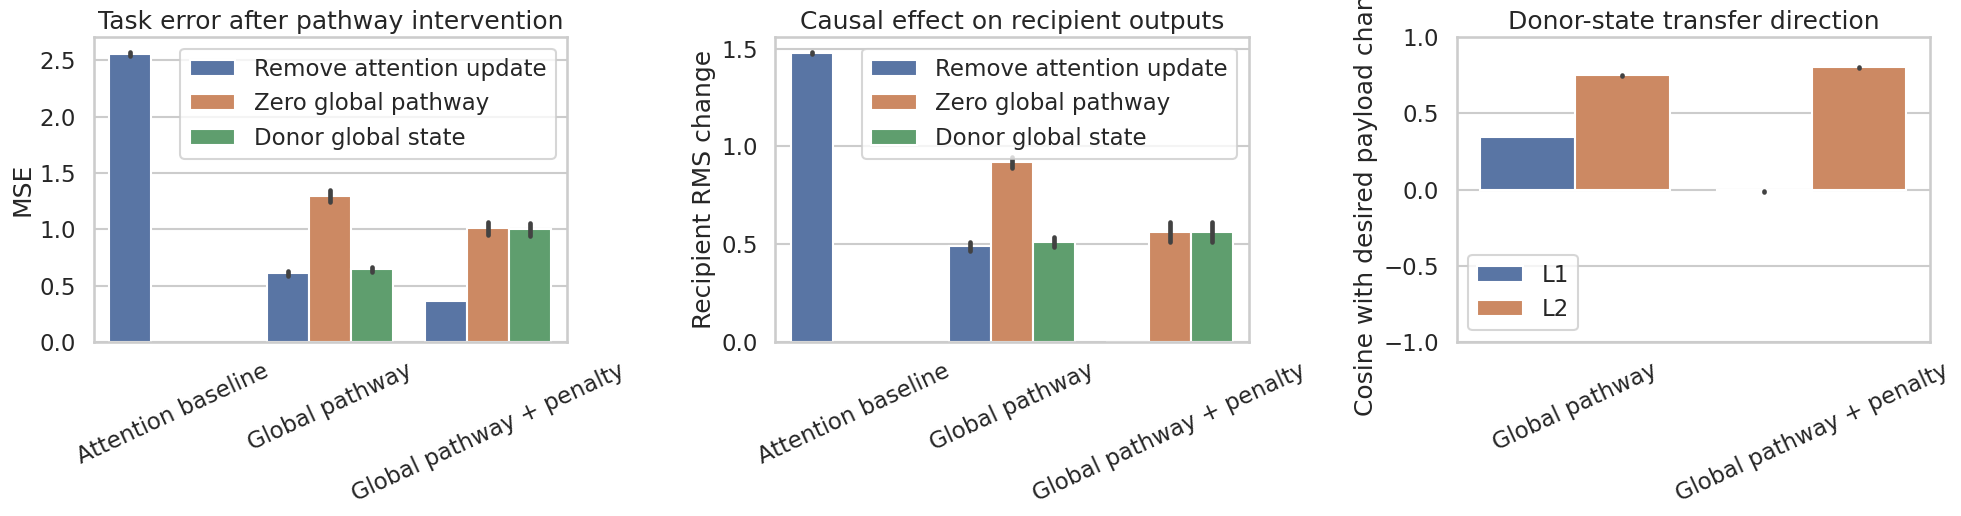

In [ ]:
primary_names = [
    "Remove attention update",
    "Zero global pathway",
    "Donor global state",
]
primary = results[results["intervention"].isin(primary_names)].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
sns.barplot(
    data=primary,
    x="variant", y="task_mse", hue="intervention", errorbar="se", ax=axes[0]
)
axes[0].set_title("Task error after pathway intervention")
axes[0].set_xlabel("")
axes[0].set_ylabel("MSE")

sns.barplot(
    data=primary,
    x="variant", y="final_delta_rms_recipients", hue="intervention",
    errorbar="se", ax=axes[1]
)
axes[1].set_title("Causal effect on recipient outputs")
axes[1].set_xlabel("")
axes[1].set_ylabel("Recipient RMS change")

donor_global = results[results["intervention"] == "Donor global state"]
sns.barplot(
    data=donor_global,
    x="variant", y="donor_payload_transfer_cosine", hue="layer",
    errorbar="se", ax=axes[2]
)
axes[2].set_title("Donor-state transfer direction")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cosine with desired payload change")
axes[2].set_ylim(-1, 1)

for ax in axes:
    ax.tick_params(axis="x", rotation=25)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "primary_causal_relocation.pdf", bbox_inches="tight")
plt.show()

## Routing and pathway diagnostics

These diagnostics prevent a false positive in which the penalty reduces output magnitude without changing concentrated routing. Inspect attention common-mode fraction and maximum column inflow together. In the desired solution, attention-side shared energy and causal importance fall, global-pooling source selection remains accurate, and the global update becomes causally dominant.

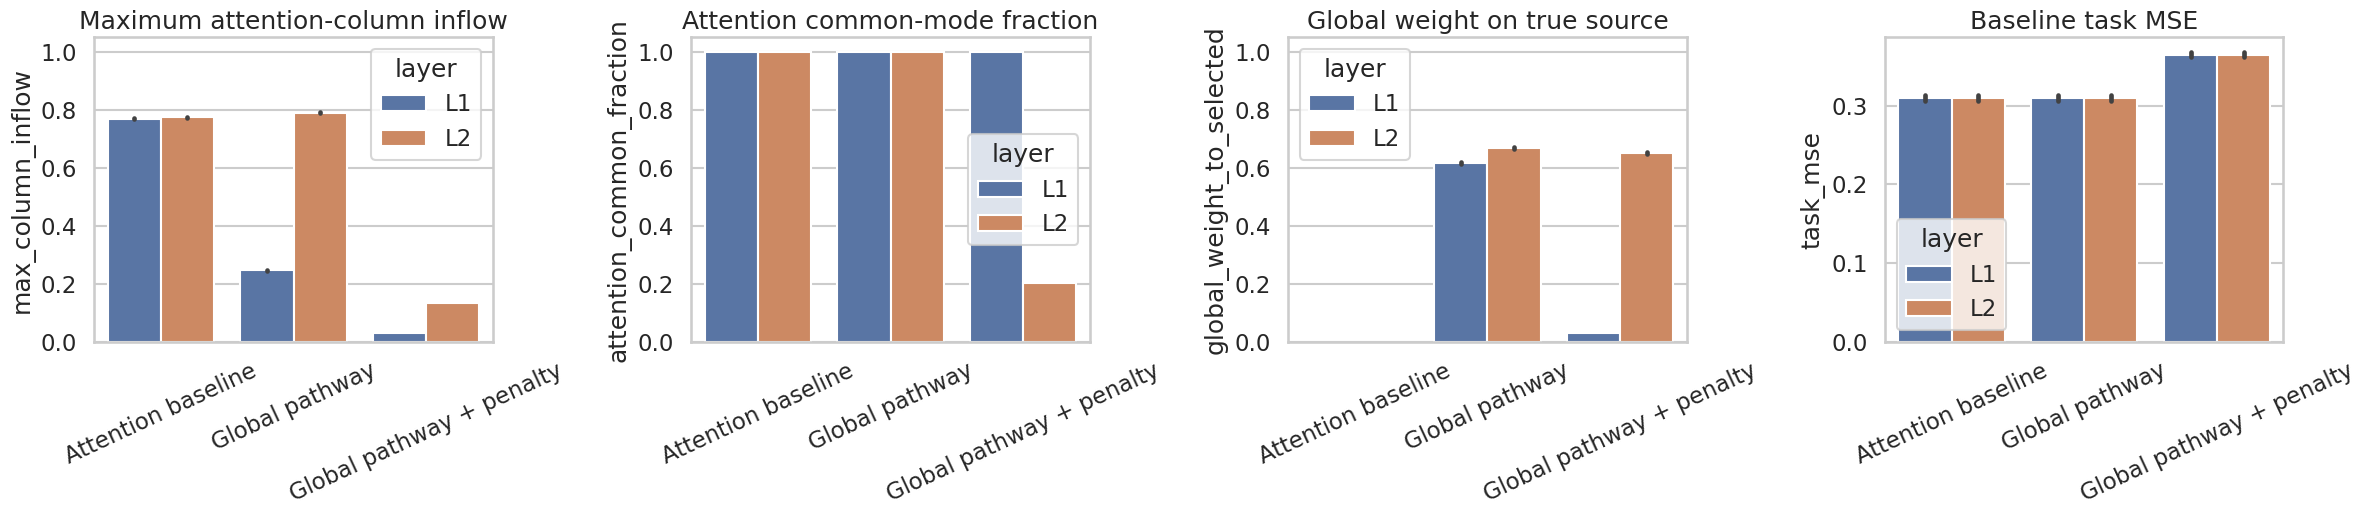

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))

diagnostics = [
    ("max_column_inflow", "Maximum attention-column inflow", (0, 1.05)),
    ("attention_common_fraction", "Attention common-mode fraction", (0, 1.05)),
    ("global_weight_to_selected", "Global weight on true source", (0, 1.05)),
    ("task_mse", "Baseline task MSE", None),
]

for ax, (metric, title, ylim) in zip(axes, diagnostics):
    sns.barplot(
        data=routing, x="variant", y=metric, hue="layer", errorbar="se", ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    if ylim is not None:
        ax.set_ylim(*ylim)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "routing_and_pathway_diagnostics.pdf", bbox_inches="tight")
plt.show()